In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from matplotlib.pyplot import figure
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import NuSVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('creditcard.csv')

data['Time'] = data['Time']/3600
bins = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6','6-7', '7-8', '8-9','9-10', '10-11', '11-12', '12-13', '13-14', '14-15','15-16', '16-17', '17-18','18-19','19-20','20-21', '21-22', '22-23', '23-24', '24-25','25-26', '26-27', '27-28','28-29','29-30','30-31', '31-32', '32-33', '33-34', '34-35','35-36', '36-37', '37-38','38-39','39-40','40-41', '41-42', '42-43', '43-44', '44-45','45-46', '46-47', '47-48']
data['Time'] = pd.cut(data['Time'], bins, labels = labels,include_lowest = True)
convert_time = {"Time": {"47-48": "23-24","46-47": "22-23","45-46": "21-22","44-45": "20-21","43-44": "19-20","42-43": "18-19","41-42": "17-18","40-41": "16-17","39-40": "15-16","38-39": "14-15","37-38": "13-14","36-37": "12-13","35-36": "11-12","34-35": "10-11","33-34": "9-10","32-33": "8-9","31-32": "7-8","30-31": "6-7","29-30": "5-6","28-29": "4-5","27-28": "3-4","26-27": "2-3","25-26": "1-2","24-25": "0-1"}}
data = data.replace(convert_time)
print(data)

         Time         V1         V2        V3        V4        V5        V6  \
0         0-1  -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1         0-1   1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2         0-1  -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3         0-1  -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4         0-1  -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...       ...        ...        ...       ...       ...       ...       ...   
284802  23-24 -11.881118  10.071785 -9.834783 -2.066656 -5.364473 -2.606837   
284803  23-24  -0.732789  -0.055080  2.035030 -0.738589  0.868229  1.058415   
284804  23-24   1.919565  -0.301254 -3.249640 -0.557828  2.630515  3.031260   
284805  23-24  -0.240440   0.530483  0.702510  0.689799 -0.377961  0.623708   
284806  23-24  -0.533413  -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8        V9  ...       V21

                 V1            V2            V3            V4            V5  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15  9.604066e-16   
std    1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min   -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%    1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15  2.239053e-15   
std    1.332271e+00  1.237094e+00  1.194353e+00  1.

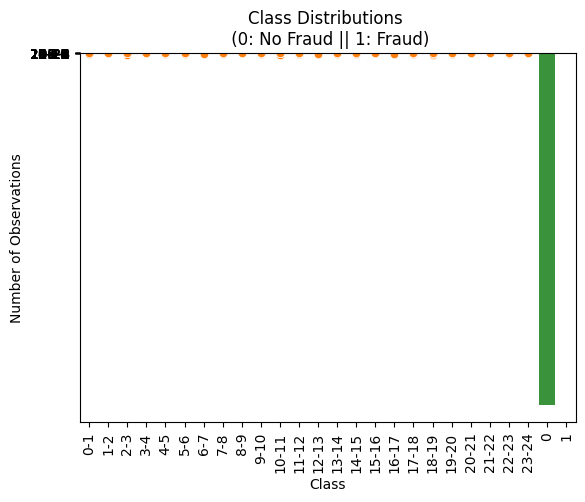

In [ ]:
"Exploratory Data Analysis"
# Generate descriptive statistics that summarize the dataset
print(data.describe())

# Shape of the dataset
print(data.shape)

# Extracting the dataset information
print(data.info)

# Checking the Null Values in the dataset
print(data.isnull().sum())

# Checking the Column Names in the dataset
print(data.columns)

# Time when Fraud happend.
data_Fraud = data[data['Class']==1]
sns.countplot(data_Fraud['Time'])
plt.xticks(rotation=90)

#Amount of Fraud happened at each hour of day.
sns.scatterplot(x=data_Fraud['Time'], y=data_Fraud['Amount'])
plt.xticks(rotation=90)

#The classes are imbalanced and we need to solve this issue later.
Fraud = data['Class'].value_counts()[0]
Non_Fraud = data['Class'].value_counts()[1]

# Total Percentage of Fraud and Non Fraud Transactions.
print("No Frauds",data['Class'].value_counts()[0]/len(data) * 100,"%")
print("Frauds",data['Class'].value_counts()[1]/len(data) * 100,"%")

#Analysing the Class Column: It seems that most of the transactions are non-fraud.
sns.countplot(x='Class', data=data)
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)')

# #Dropping Time Column since it is not giving any insights.
data = data.drop('Time',axis=1)
print(data)

#Sum of Fraud Transaction
Fraud_Transaction = data[data['Class'] == 1]['Amount'].sum()
print("The sum of Fraud Transaction is:",Fraud_Transaction)


<Figure size 640x480 with 0 Axes>

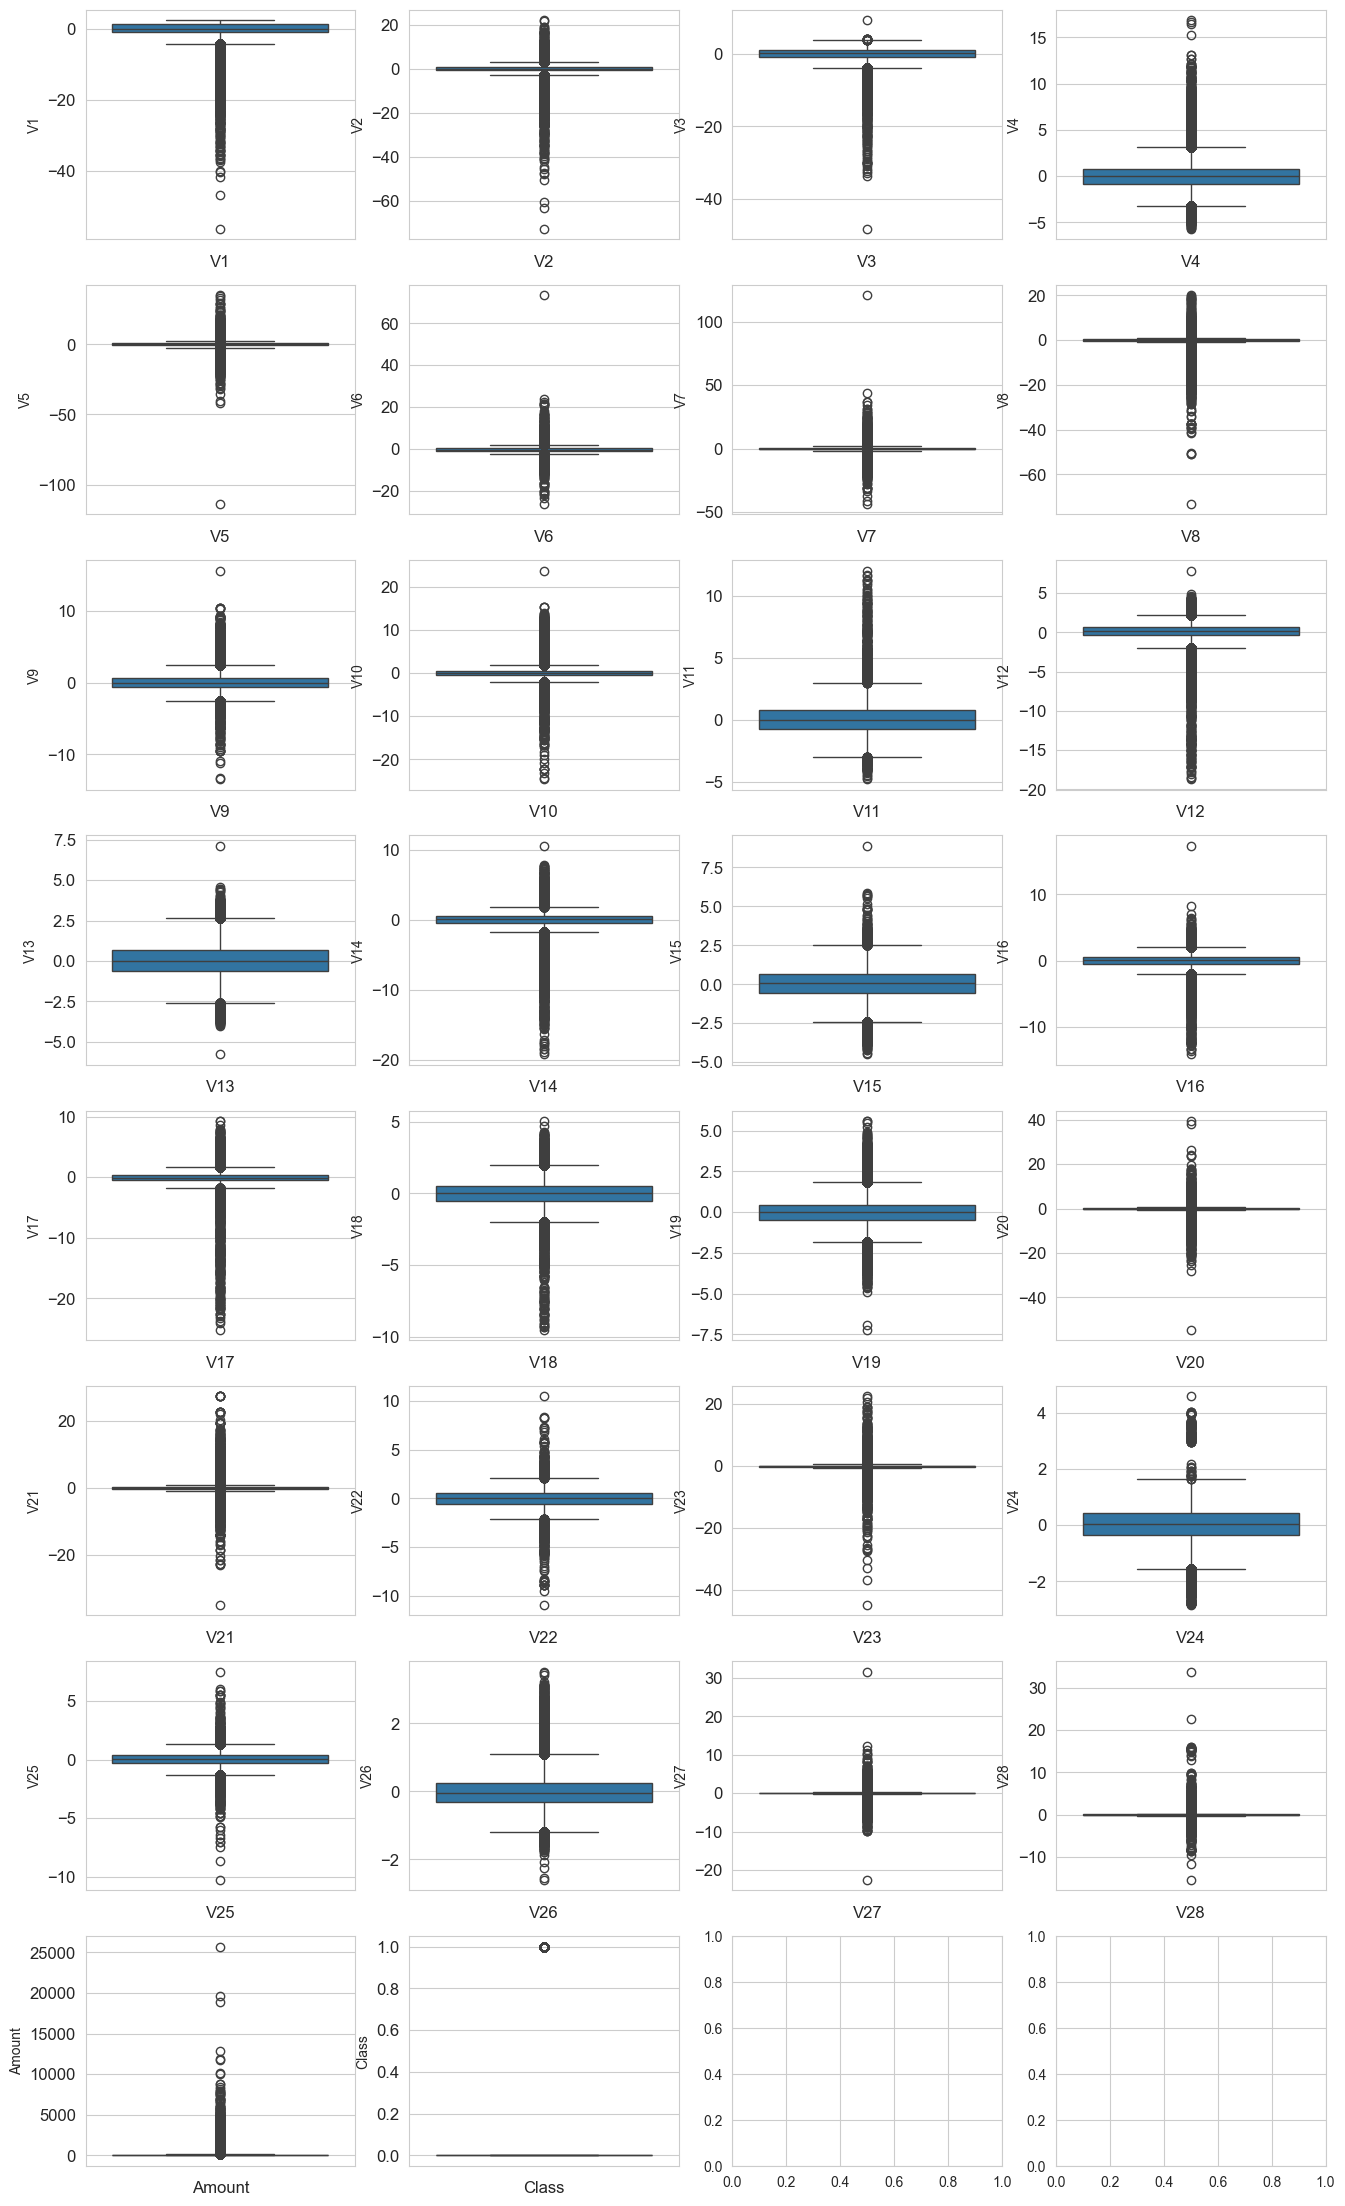

In [ ]:
#Selecting X and Y parameters to train the Model.
X = data.drop(columns = 'Class', axis=1)
y = data['Class']

#Detecting Outliers in the Dataset
i=0
feature_name = data.columns.values
sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))
for feature in feature_name:
    i += 1
    plt.subplot(8,4,i)
    sns.boxplot(data[feature])
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

# Function to remove Outliers from the Dataset
def remove_outlier(data_in, col_name):
    # calculate interquartile range
    q1 = data_in[col_name].quantile(0.25)
    q3 = data_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q1, q3, iqr))
    low  = q1-1.5*iqr
    high = q3+1.5*iqr
    df_out = data_in.loc[(data_in[col_name] > low) & (data_in[col_name] < high)]
    outliers = data_in.loc[(data_in[col_name] < low) | (data_in[col_name] > high)]
    return df_out

In [ ]:
# Apply SelectKBest class to extract top 10 best features
X_norm = MinMaxScaler().fit_transform(X)
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X_norm,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns,dfscores],axis=1) #concat two dataframes for better visualization
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #This will print 10 best features

   Specs      Score
10   V11  88.222110
3     V4  79.307556
13   V14  41.919315
11   V12  38.953409
16   V17  25.287263
15   V16  19.011503
17   V18  18.006508
9    V10  13.364745
2     V3   8.742138
8     V9   8.419628


<Figure size 640x480 with 0 Axes>

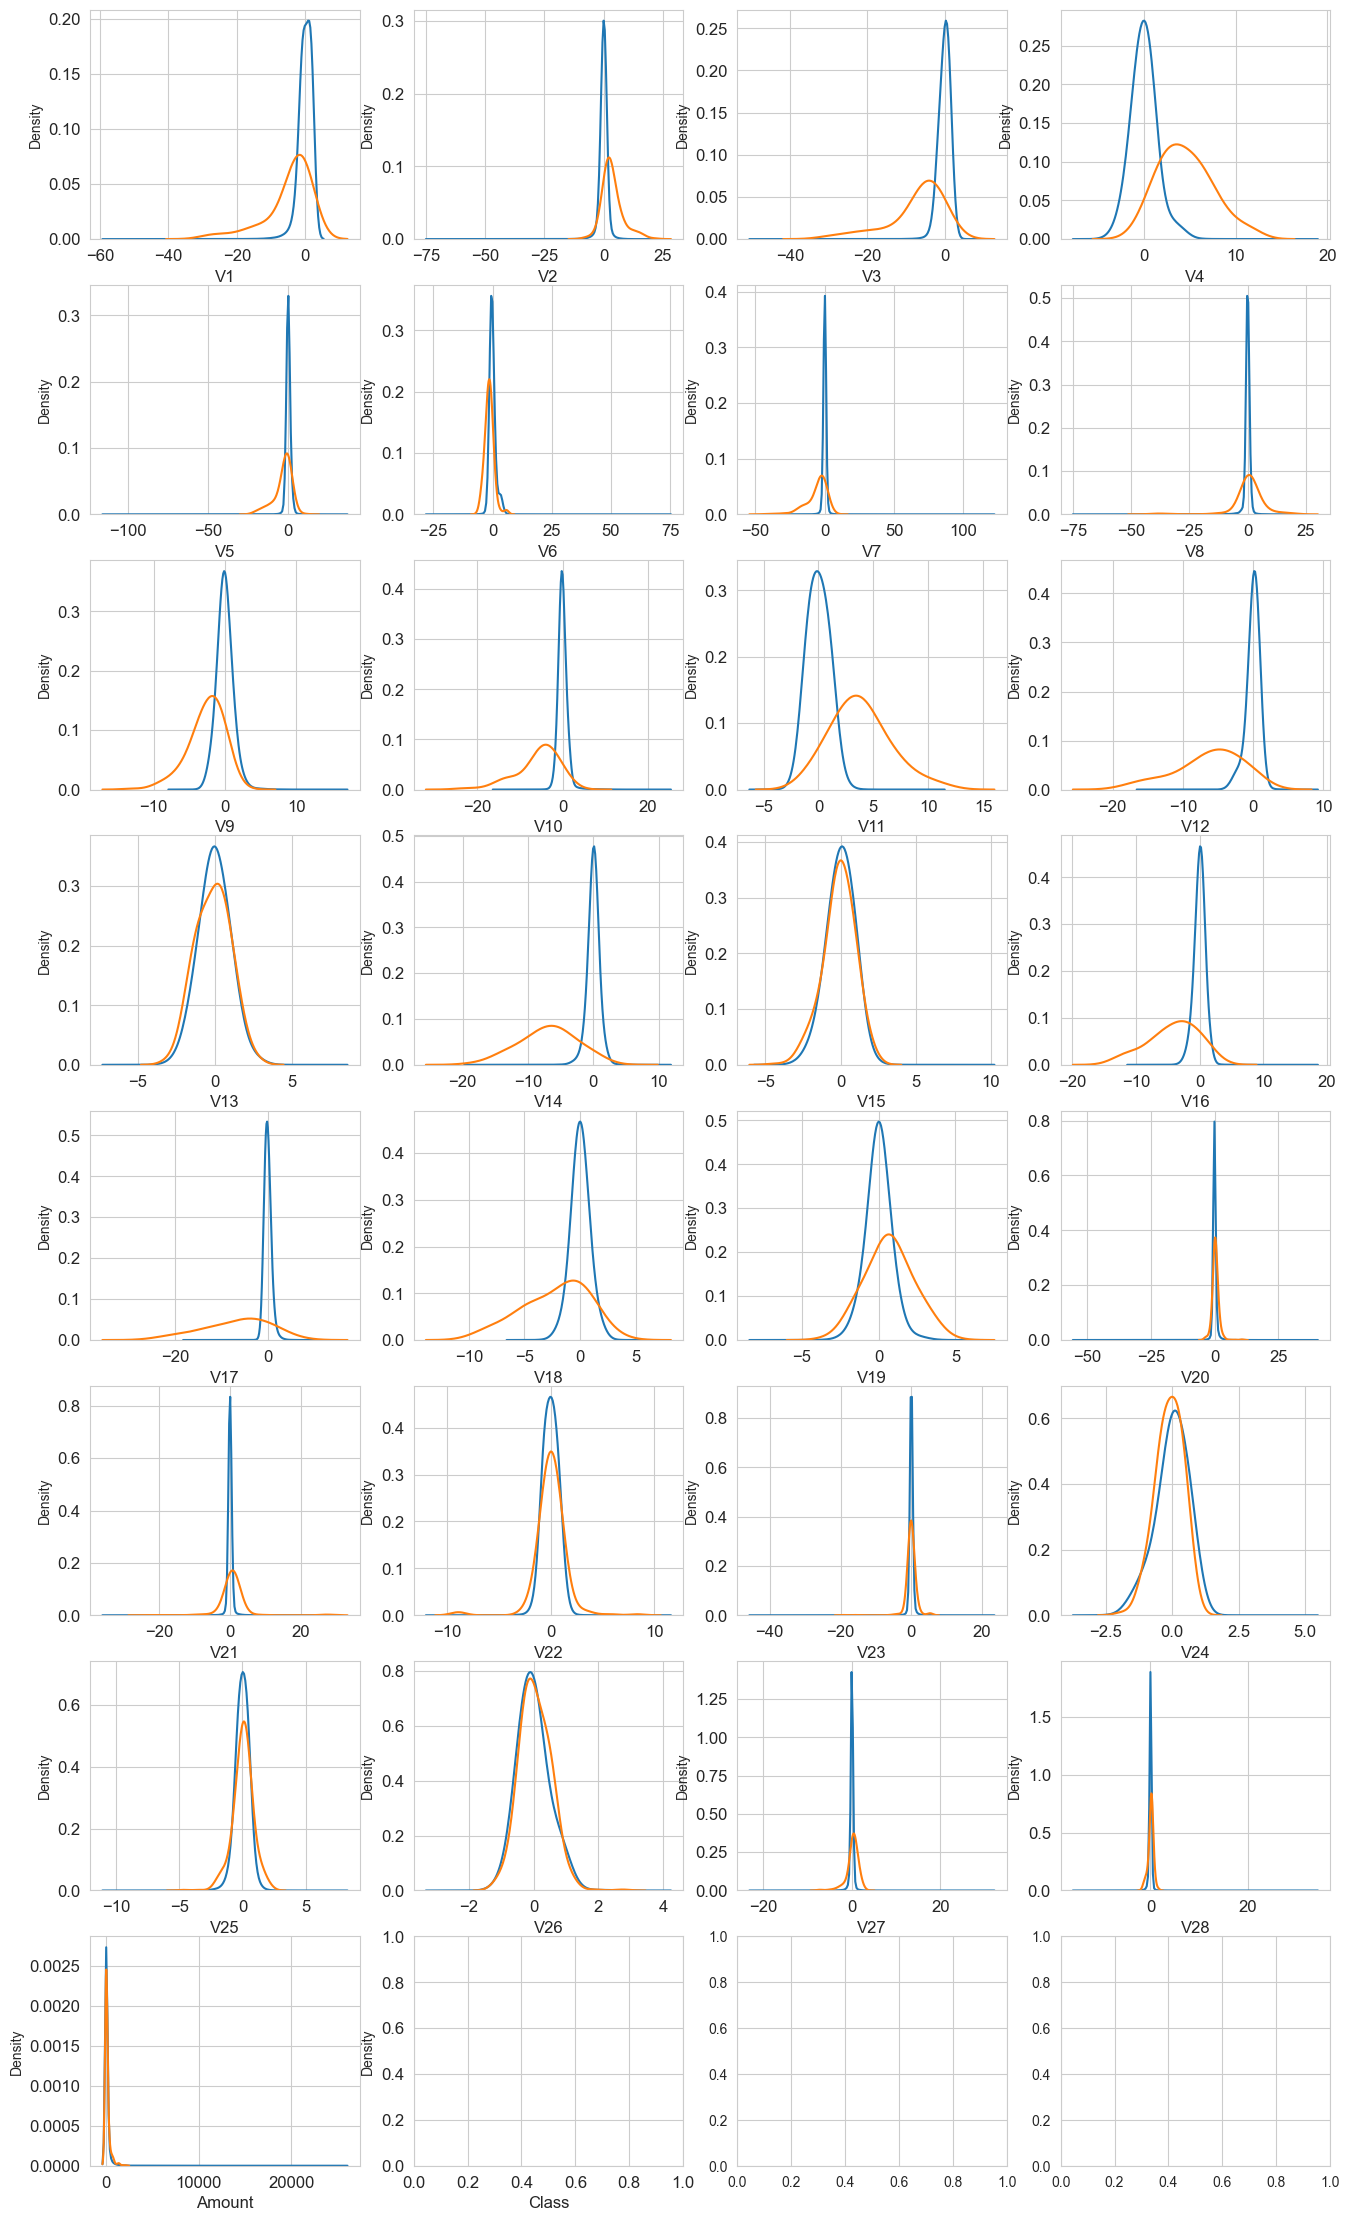

In [ ]:
# Kernel density estimation (KDE) plots: This should give us a clear idea of how fraudulent and non fraudulent transactions are distributed along each variable.
i=0
feature_name = data.columns.values
C0 = data.loc[data['Class'] == 0]
C1 = data.loc[data['Class'] == 1]
sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))
for feature in feature_name:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(C0[feature], bw=0.5,label="Class = 0")
    sns.kdeplot(C1[feature], bw=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();

#Observarion:
# 1. The distribution of the fraudulent transaction takes a shape that very close to a Normal Distribution.
# 2. The distribution of the non fraudulent transaction takes a shape that very close to the Standard Normal Distribution.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

#Before applying SMOTE.
print("Xtrain.shape : ", X_train.shape)
print("Xtest.shape  : ", X_test.shape)
print("Ytrain.shape : ", y_train.shape)
print("Ytest.shape  : ", y_test.shape)

#Sampling the data so that we have equal number of "Class 0" and "Class 1"
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state= 42)
X_train_sample, y_train_sample = sm.fit_resample(X_train,y_train)


#After applying SMOTE.
print("Xtrain.shape : ", X_train_sample.shape)
print("Xtest.shape  : ", X_test.shape)
print("Ytrain.shape : ", y_train_sample.shape)
print("Ytest.shape  : ", y_test.shape)

#Dataset has now balanced i.e., it has equal number of "0" and "1".
print(y_train_sample.value_counts())

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


Xtrain.shape :  (199364, 29)
Xtest.shape  :  (85443, 29)
Ytrain.shape :  (199364,)
Ytest.shape  :  (85443,)
Xtrain.shape :  (398038, 29)
Xtest.shape  :  (85443, 29)
Ytrain.shape :  (398038,)
Ytest.shape  :  (85443,)
Class
0    199019
1    199019
Name: count, dtype: int64


In [ ]:
def print_scores(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))


In [ ]:
# 1. Logistic Regression
model = LogisticRegression()
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Logistic Regression")


--- Logistic Regression ---
Accuracy : 0.9825380663132146
Precision: 0.08099688473520249
Recall   : 0.8843537414965986
F1 Score : 0.14840182648401826


In [ ]:
# 2. K-Nearest Neighbors
model = KNeighborsClassifier(metric='manhattan', n_neighbors=2, weights='uniform')
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "K-Nearest Neighbors")


--- K-Nearest Neighbors ---
Accuracy : 0.9990402958697612
Precision: 0.6923076923076923
Recall   : 0.7959183673469388
F1 Score : 0.740506329113924


In [ ]:
# 3. Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Decision Tree")



--- Decision Tree ---
Accuracy : 0.9973900729141065
Precision: 0.37333333333333335
Recall   : 0.7619047619047619
F1 Score : 0.5011185682326622


In [ ]:
# 4. Naive Bayes
model = GaussianNB()
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Naive Bayes")


--- Naive Bayes ---
Accuracy : 0.9753285816275178
Precision: 0.05733634311512415
Recall   : 0.8639455782312925
F1 Score : 0.10753598645215919


In [ ]:
# 5. Random Forest
model = RandomForestClassifier(n_estimators=100, max_features=3)
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Random Forest")


--- Random Forest ---
Accuracy : 0.9995084442259752
Precision: 0.8832116788321168
Recall   : 0.8231292517006803
F1 Score : 0.852112676056338


In [ ]:
# 6. Support Vector Machine
model = LinearSVC()
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Support Vector Machine")


--- Support Vector Machine ---
Accuracy : 0.9860257715670095
Precision: 0.09946442234123948
Recall   : 0.8843537414965986
F1 Score : 0.17881705639614856


In [ ]:
# 7. XGBoost
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "XGBoost")


--- XGBoost ---
Accuracy : 0.9993679997191109
Precision: 0.8120805369127517
Recall   : 0.8231292517006803
F1 Score : 0.8175675675675675


In [ ]:
# 8. Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(X_train_sample, y_train_sample)
y_pred = model.predict(X_test)
print_scores(y_test, y_pred, "Gradient Boosting")


--- Gradient Boosting ---
Accuracy : 0.9931650339992744
Precision: 0.1847041847041847
Recall   : 0.8707482993197279
F1 Score : 0.3047619047619048
